https://rbrooksdk.github.io/STA1_26/assignments/assignment_02_discrete_and_continuous_models/

In [37]:
from IPython.display import display, Markdown
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Part 1 — Cooling-unit failures: a finite random variable
## Let $X$ be the number of cooling units that fail during a weekly maintenance window. The engineering model is

|      $x$ |    0 |    1 |    2 |    3 |    4 |
| -------: | ---: | ---: | ---: | ---: | ---: |
| $P(X=x)$ | 0.58 | 0.26 | 0.10 | 0.04 | 0.02 |


### a) Verify that the table is a valid PMF, state the support, and distinguish the random variable $X$ from an observed value $x$ .

### b) Construct a table containing $x$, $p_X(x)$, and $F_X(x)$. Use it to calculate $P(X=2)$, $P(X\leq1)$, $P(X\geq2)$, and $P(1<X\leq3)$.


### c) Plot the PMF as a bar chart and the CDF as a step plot. Explain the meaning of the height at each value in both plots.

### d) Calculate and interpret $E[X]$, $Var(X)$, and $SD(X)$.

# Part 2 — Repeated-event count models
# Late supplier deliveries: binomial

## A project expects 30 deliveries. Each is modelled as late with probability 0.12 independently of the others. Let be the number of late deliveries.

### a) Justify $B \sim Bin(30, 0.12)$. Identify the Bernoulli trial and discuss fixed $n$, constant $p$, independence, and one realistic violation.

### b) Use SciPy to calculate $P(B=3)$, $P(B\leq4)$, and $P(B\geq5)$. For $P(B=3)$, also show the binomial formula and explain $\binom{n}{k}$. For the upper tail, explain the correct survival-function argument.


### c) Calculate and interpret the mean and standard deviation.

# Production stoppages: Poisson

## Short stoppages are modelled as a Poisson process with mean 1.6 per 8-hour shift. Let be the count during one shift.

### a) State the model, parameter, support, mean, and variance. Calculate $P(Y=0)$ and $P(Y \geq 3)$ for one shift.

### b) Scale the expected count and calculate the probability of at least three stoppages in 24 hours. Discuss the stable-rate and independent-event assumptions.

# Part 3 — Uniform and normal models
# Sensor polling delay: uniform

## A monitoring device polls a sensor once every 12 seconds. An event is assumed to occur at a random point in the cycle, so the delay $D$ until the next poll is modelled as $D \sim Uniform(0, 12)$ .

### a) Create the SciPy model using the correct location and scale. Plot its PDF and CDF and explain the support, constant density, and why $P(D=d) = 0$.

Support = (0.0, 12.0)


Text(0.5, 1.0, 'CDF')

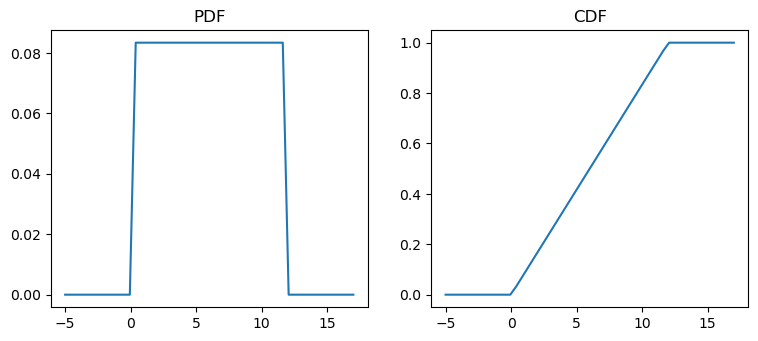

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

D = stats.uniform(loc=0, scale=12)

print(f"Support = {D.support()}")

xs = np.linspace(-5, 17)

axes[0].plot(xs, D.pdf(xs))
axes[0].set_title("PDF")
axes[1].plot(xs, D.cdf(xs))
axes[1].set_title("CDF")

1. Support is 0 to 12, since that is the provided range.
2. PDF is constant because the probability is uniform, so it's equal across the whole support
3. $P(D=d) = 0$ because time is continous and as such when trying to calculate the probability of exactly $t$ we get $ \int_t^t \frac{1}{12} = 0$

### b) Calculate $P(D \leq 3)$, $P(4 \leq D \leq 9)$, $P(D \geq 10)$, the mean, standard deviation, and 95th percentile.

In [39]:
a = D.cdf(3)
b = D.cdf(9) - D.cdf(4)
c = 1 - D.cdf(10)
mean = D.mean()
sd = D.std()
nfth = D.ppf(0.95)

display(Markdown(f"""
$P(D \\leq 3) = {a}$

$P(4 \\leq D \\leq 9) = {b}$,

$P(D \\geq 10) = {c}$

Mean = {mean}

Standard deviation = {sd}

95th percentile = {nfth}
"""))


$P(D \leq 3) = 0.25$

$P(4 \leq D \leq 9) = 0.4166666666666667$,

$P(D \geq 10) = 0.16666666666666663$

Mean = 6.0

Standard deviation = 3.4641016151377544

95th percentile = 11.399999999999999


# Concrete strength: normal working model

## The file assignment02_concrete_strength.csv contains 160 compressive-strength measurements. Treat the generating parameters as unknown.

In [40]:
cs_df = pd.read_csv("./assignment02_concrete_strength.csv")

### a) Report $n$, mean, median, and sample standard deviation. Fit $N(\hat{\mu}, \hat{\sigma}^2)$ and explain why SciPy receives $\hat{\sigma}$, not $\hat{\sigma}^2$, as `scale`.


In [41]:
[n, mean, std] = cs_df['strength_mpa'].describe()[['count', 'mean', 'std']]
median = cs_df['strength_mpa'].median()
print(f"n \t\t\t{n}")
print(f"mean \t\t\t{mean}")
print(f"median \t\t\t{median}")
print(f"standard deviation \t{std}")

N = stats.norm(loc=mean, scale=std)
print("\nSciPy receives standard deviation instead of variance since that is how it was programmed? Feasiably because it's easier to program")

n 			160.0
mean 			42.494187499999995
median 			42.379999999999995
standard deviation 	4.342912605813011

SciPy receives standard deviation instead of variance since that is how it was programmed? Feasiably because it's easier to program


### b) Plot a density histogram with the fitted PDF and create a normal QQ-plot. Discuss symmetry, tails, unusual observations, and model adequacy.

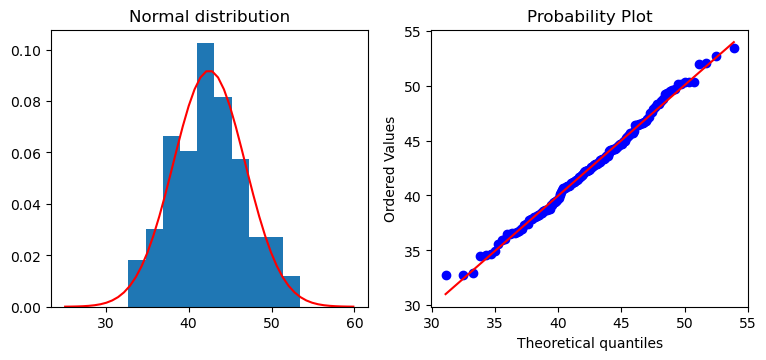


#### Altogether the normal distribution seems to represent the data well, the only surprise is the 41-42 bucket which is noticably bigger in the actual data, and 40-41 which is noticably smaller. 
#### We can further see the adequacy on the QQ graph which aligns well. 
#### The data gathered seems symmetrical around the well pronounced 41-42 bucket and has no noticable tails.

In [42]:
xs = np.linspace(mean - 4*std, mean + 4*std)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

axes[0].set_title("Normal distribution")
axes[0].plot(xs, N.pdf(xs), color="red", label="Normal PDF")
axes[0].hist(cs_df['strength_mpa'], density=True)

axes[1].set_title("QQ-plot")
stats.probplot(cs_df['strength_mpa'], dist=N, plot=axes[1])

plt.show()
display(Markdown("""
#### Altogether the normal distribution seems to represent the data well, the only surprise is the 41-42 bucket which is noticably bigger in the actual data, and 40-41 which is noticably smaller. 
#### We can further see the adequacy on the QQ graph which aligns well. 
#### The data gathered seems symmetrical around the well pronounced 41-42 bucket and has no noticable tails."""))

### c) From the fitted model, calculate $P(X < 35)$, $P(38 < X < 46)$, the 95th percentile, and the $z$-score of 35 MPa. Compare the first two model probabilities with empirical proportions.

In [43]:
a = N.cdf(35)
b = N.cdf(46) - N.cdf(38)
nfth = N.ppf(0.95)

zScore = (35 - mean) / std

display(Markdown(f"""
$P(X < 35) = {a}$

$P(38 < X < 46) = {b}$

$95th$ percentile = ${nfth}$

$z$-score at 35MPa = ${zScore}$

"""))


$P(X < 35) = 0.04220850775780514$

$P(38 < X < 46) = 0.6398649723188448$

$95th$ percentile = $49.6376430512048$

$z$-score at 35MPa = $-1.7256132416685028$



In [44]:
## Empirical comparison:
mpa = cs_df['strength_mpa']
ptf = mpa.loc[mpa < 35].count() / mpa.count()
ptefs = mpa.loc[mpa > 38].loc[mpa < 46].count() / mpa.count()

display(Markdown(f"""
$P(X < 35) = {ptf}$

$P(38 < X < 46) = {ptefs}$

### The differences between probabilities calculated from the fitted normal distribution and the actual data:

${ptf} - {a} = {ptf - a}$

${ptefs} - {b} = {ptefs - b}$

### the differences are not significant, 0.1% and 0.2%
"""))


$P(X < 35) = 0.04375$

$P(38 < X < 46) = 0.6375$

### The differences between probabilities calculated from the fitted normal distribution and the actual data:

$0.04375 - 0.04220850775780514 = 0.0015414922421948599$

$0.6375 - 0.6398649723188448 = -0.0023649723188448046$

### the differences are not significant, 0.1% and 0.2%


# Part 4 — Service restoration: an exponential working model

## The file assignment02_service_repairs.csv contains 180 restoration times from independent service incidents. Treat the rate as unknown.

### a) Report $n$, mean, median, sample standard deviation, minimum, and maximum. Plot a density histogram and describe the shape.

In [45]:
sr_df = pd.read_csv("./assignment02_service_repairs.csv")
T_data = sr_df['repair_time_min']

n = T_data.count()
mean = T_data.mean()
median = T_data.median()
std = T_data.std()
t_min = T_data.min()
t_max = T_data.max()

print(f"n \t\t\t{n}")
print(f"mean \t\t\t{mean}")
print(f"median \t\t\t{median}")
print(f"standard deviation \t{std}")
print(f"minimum \t\t{t_min}")
print(f"maximum \t\t{t_max}")

n 			180
mean 			69.79861111111111
median 			49.345
standard deviation 	67.43318667051601
minimum 		1.11
maximum 		410.66


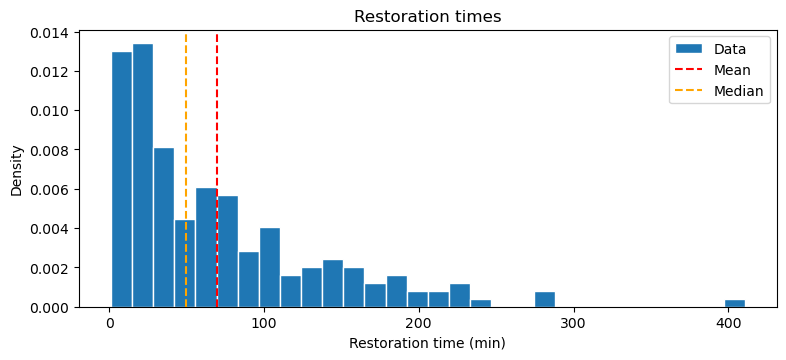

In [46]:
fig, ax = plt.subplots(figsize=(9, 3.6))

ax.set_title("Restoration times")
ax.hist(T_data, bins=30, density=True, edgecolor="white", label="Data")
ax.axvline(mean, color="red", linestyle="--", label="Mean")
ax.axvline(median, color="orange", linestyle="--", label="Median")
ax.set_xlabel("Restoration time (min)")
ax.set_ylabel("Density")
ax.legend()

plt.show()

Strongly right-skewed: peak near 0, steep drop, then a long tail up to ≈ 410 min.
- Mean (69.8) > median (49.3) confirms the right skew. Half of incidents are restored within ≈ 49 min.
- Mean ≈ SD (69.8 vs 67.4), which matches $E[T] = SD(T) = 1/\lambda$ for an exponential.

### b) Fit an exponential model using $\hat{\lambda} = 1/\bar{x}$. State its fitted rate, mean, variance, and SciPy scale and add the fitted PDF to the histogram.


Fitted rate $\hat{\lambda} = 0.01433$ per minute

Mean $= 1/\hat{\lambda} = 69.80$ min

Variance $= 1/\hat{\lambda}^2 = 4871.85$ min²

SciPy `scale` $= 1/\hat{\lambda} = 69.80$ min, `loc` $= 0$


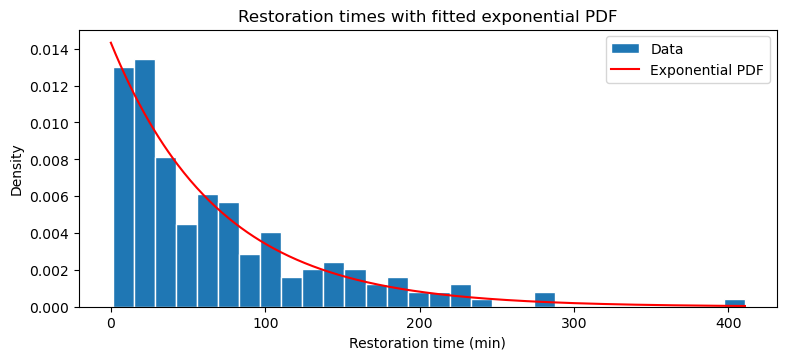

In [47]:
lam_hat = 1 / mean
E = stats.expon(loc=0, scale=1/lam_hat)

display(Markdown(f"""
Fitted rate $\\hat{{\\lambda}} = {lam_hat:.5f}$ per minute

Mean $= 1/\\hat{{\\lambda}} = {E.mean():.2f}$ min

Variance $= 1/\\hat{{\\lambda}}^2 = {E.var():.2f}$ min²

SciPy `scale` $= 1/\\hat{{\\lambda}} = {E.kwds['scale']:.2f}$ min, `loc` $= 0$
"""))

xs = np.linspace(0, t_max, 400)

fig, ax = plt.subplots(figsize=(9, 3.6))

ax.set_title("Restoration times with fitted exponential PDF")
ax.hist(T_data, bins=30, density=True, edgecolor="white", label="Data")
ax.plot(xs, E.pdf(xs), color="red", label="Exponential PDF")
ax.set_xlabel("Restoration time (min)")
ax.set_ylabel("Density")
ax.legend()

plt.show()

### c) Compare empirical and fitted distributions using an empirical CDF with fitted CDF or an exponential QQ-plot. Discuss model strengths and limitations.

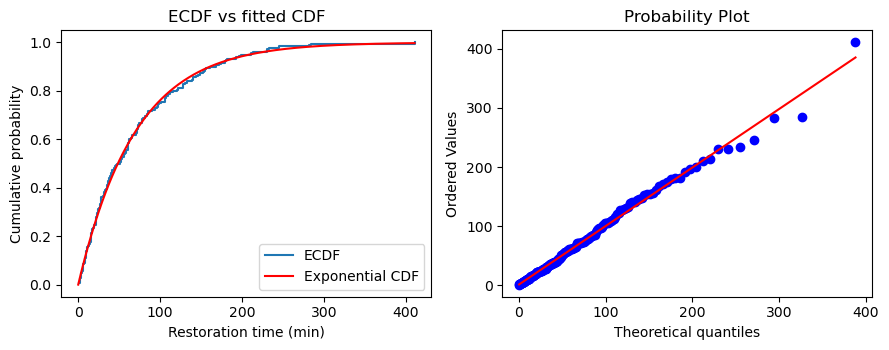

In [48]:
t_sorted = np.sort(T_data)
ecdf = np.arange(1, n + 1) / n

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

axes[0].set_title("ECDF vs fitted CDF")
axes[0].step(t_sorted, ecdf, where="post", label="ECDF")
axes[0].plot(xs, E.cdf(xs), color="red", label="Exponential CDF")
axes[0].set_xlabel("Restoration time (min)")
axes[0].set_ylabel("Cumulative probability")
axes[0].legend()

axes[1].set_title("Exponential QQ-plot")
stats.probplot(T_data, dist=E, plot=axes[1])

plt.tight_layout()
plt.show()

**Strengths:** ECDF and fitted CDF almost overlap (max gap ≈ 0.03), and the QQ-plot follows the line up to ≈ 220 min. Correct support $[0, \infty)$.

**Limitations:**
- The largest values fall slightly below the QQ line, so the tail is a bit lighter than the model's.
- There is only one parameter, so the spread is fixed by the mean (model var ≈ 4872 vs sample ≈ 4547).
- The tail rests on few observations.
- A constant repair rate is unlikely for a mix of simple and complex incidents.

### d) Calculate and interpret $P(T \leq 30)$, $P(T > 120)$, the median, and the 90th percentile. Compare the two model probabilities with empirical proportions.

In [49]:
a = E.cdf(30)
b = E.sf(120)
t_median = E.ppf(0.5)
t_90 = E.ppf(0.9)

## Empirical proportions
emp_a = (T_data <= 30).mean()
emp_b = (T_data > 120).mean()

display(Markdown(f"""
$P(T \\leq 30) = {a:.4f}$

$P(T > 120) = {b:.4f}$

Median $= \\ln(2)/\\hat{{\\lambda}} = {t_median:.2f}$ min

90th percentile $= {t_90:.2f}$ min

### Model vs empirical proportions:

| | Model | Empirical | Difference |
|---|---|---|---|
| $P(T \\leq 30)$ | {a:.4f} | {emp_a:.4f} | {emp_a - a:.4f} |
| $P(T > 120)$ | {b:.4f} | {emp_b:.4f} | {emp_b - b:.4f} |
"""))


$P(T \leq 30) = 0.3494$

$P(T > 120) = 0.1792$

Median $= \ln(2)/\hat{\lambda} = 48.38$ min

90th percentile $= 160.72$ min

### Model vs empirical proportions:

| | Model | Empirical | Difference |
|---|---|---|---|
| $P(T \leq 30)$ | 0.3494 | 0.3611 | 0.0117 |
| $P(T > 120)$ | 0.1792 | 0.2000 | 0.0208 |


- $P(T \leq 30) \approx 0.35$: 35% of incidents are restored within 30 min.
- $P(T > 120) \approx 0.18$: 18% take longer than 2 hours.
- Median ≈ 48.4 min (= $\ln 2/\hat\lambda$): half are restored within ≈ 48 min.
- 90th percentile ≈ 160.7 min: 90% are restored within ≈ 2 h 40 min.

Empirical proportions are close: 0.361 vs 0.349 and 0.200 vs 0.179. The model slightly underestimates long repairs around 120 min (≈ 4 incidents).

### e) Calculate $P(T > 150 \mid T > 60)$ as both a ratio of survival probabilities and the probability of waiting an additional 90 minutes. Explain the memoryless and constant-rate assumptions.

In [50]:
cond = E.sf(150) / E.sf(60)

extra = E.sf(90)

n_60 = (T_data > 60).sum()
n_150 = (T_data > 150).sum()
emp_cond = n_150 / n_60

display(Markdown(f"""
$P(T > 150 \\mid T > 60) = \\dfrac{{P(T > 150)}}{{P(T > 60)}} = \\dfrac{{{E.sf(150):.4f}}}{{{E.sf(60):.4f}}} = {cond:.4f}$

$P(T > 90) = e^{{-90\\hat{{\\lambda}}}} = {extra:.4f}$

Empirical: {n_150} of the {n_60} incidents lasting over 60 min also lasted over 150 min, i.e. ${emp_cond:.4f}$
"""))


$P(T > 150 \mid T > 60) = \dfrac{P(T > 150)}{P(T > 60)} = \dfrac{0.1166}{0.4233} = 0.2754$

$P(T > 90) = e^{-90\hat{\lambda}} = 0.2754$

Empirical: 23 of the 80 incidents lasting over 60 min also lasted over 150 min, i.e. $0.2875$


$\{T > 150\} \cap \{T > 60\} = \{T > 150\}$, so
$$P(T > 150 \mid T > 60) = \frac{e^{-150\lambda}}{e^{-60\lambda}} = e^{-90\lambda} = P(T > 90) \approx 0.275$$

**Memoryless:** the time already spent does not change the remaining waiting time. An incident open for 60 min has the same chance of lasting 90 more minutes as a new one.

**Constant rate:** this follows from a constant $\hat\lambda \approx 0.0143$/min. It is questionable in practice (complex incidents last longer, escalation speeds things up), but the data agrees well: 23/80 = 0.288.

# Overall conclusion

## Write approximately 150–250 words comparing the probability models used in the assignment. Explain how support, mechanism, parameterisation, and graphical model assessment determine whether a calculated probability is useful.

### Only use Sessions 3–4. Do not use sampling distributions, confidence intervals, hypothesis tests, bootstrap procedures, or later methods.